# <span style="color:rgb(160,0,86)">Regressionsanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können mit der **Methode der kleinsten Quadrate** die Parameter eines Modells schätzen.
- Sie kennen die Bedeutung des **Standardfehlers der Residuen** und des **Bestimmtheitsmasses**. 
- Sie können mit einem Hypothesentest prüfen, ob der **Einfluss eines Prädiktors** signifikant ist.  
- Sie können **Konfidenzintervalle** für Prädiktoren berechnen.  
- Sie können **Vorhersageintervalle** für Schätzungen berechnen. 
***

### <span style="color:rgb(160,0,86)">Was ist eine Regressionsanalyse?</span>

Die **Regressionsanalyse** ist ein zentrales statistisches Verfahren zur **Beschreibung von Zusammenhängen** zwischen Variablen. Ziel ist es, den Einfluss einer oder mehrerer unabhängiger Variablen, 

- die so genannen **Prädiktoren** $x_1, x_2, \ldots , x_n$

auf eine abhängige Variable,

- die so genannte **Zielgrösse** $y$

zu quantifizieren und Vorhersagen zu ermöglichen. Dabei wird eine **Prädiktorfunktion** $$y=\texttt{predict}(x_1,x_2,\ldots,x_n)$$  als **Modell** verwendet, das die Beziehung zwischen den Variablen beschreibt.

Die einfachste Form ist die **lineare Einfachregression**, bei der eine abhängige Variable durch genau eine unabhängige Variable erklärt wird: $$\;\;y = \texttt{predict}(x) = a\cdot x + b$$ 

In vielen Anwendungen ist jedoch die **multiple lineare Regression** relevant, bei der mehrere Einflussgrössen gleichzeitig betrachtet werden:
$$\;\;y = \texttt{predict}(x_1,x_2,\ldots,x_n) = a_1\cdot x_1 + a_2\cdot x_2 + \ldots a_n\cdot x_n + b$$

Die *aus einer Stichprobe geschätzten* **Regressionsparameter** $\pmb{\hat{a}_1}, \pmb{\hat{a}_2}, \ldots, \pmb{\hat{a}_n}, \pmb{\hat{b}}$ geben dabei an, wie stark sich die Zielvariable verändert, wenn sich ein Prädiktor ändert – unter Konstanthaltung aller anderen Variablen. Wir bezeichen daher die $\pmb{\hat{a}_i}$ auch als **Gewichte der Prädiktoren** $\pmb{x_i}$.
- Das **Gewicht** $\pmb{\hat{a}_i}$ beschreibt also, wie gross der **Einfluss des Prädiktors** $\pmb{x_i}$ auf die Zielgrösse ist. $$\begin{align*}\text{Gewicht }\,\pmb{\hat{a}_i=0} \quad&\Longrightarrow\quad \pmb{\hat{a}_ix_i = 0}\;\,\text{ f\"ur alle }\, \pmb{x_i}\\ &\Longrightarrow\quad \pmb{x_i}\, \text{ hat keinen Einfluss auf die Zielgr\"osse }\,\pmb{y}\rule{0cm}{1cm}\\ \text{Gewicht }\,\pmb{\hat{a}_i>0} \quad&\Longrightarrow\quad \pmb{\hat{a}_ix_i > 0}\;\,\text{ f\"ur alle }\, \pmb{x_i>0} \rule{0cm}{1cm}\\ &\Longrightarrow\quad \text{je gr\"osser }\,\pmb{x_i}\ \text{desto grösser die Zielgr\"osse }\,\pmb{y}\rule{0cm}{1cm} \\ \text{Gewicht }\,\pmb{\hat{a}_i<0} \quad&\Longrightarrow\quad \pmb{\hat{a}_ix_i < 0}\;\,\text{ f\"ur alle }\, \pmb{x_i>0} \rule{0cm}{1cm}\\ &\Longrightarrow\quad \text{je gr\"osser }\,\pmb{x_i}\ \text{desto kleiner die Zielgr\"osse }\,\pmb{y}\rule{0cm}{1cm}\end{align*}$$

Neben der Schätzung der Modellparameter erlaubt die Regressionsanalyse auch 
- die **statistische Bewertung der Modellgüte**,
- die **Signifikanzprüfung einzelner Prädiktoren** und
- die **Quantifizierung der Vorhersageunsicherheit**. 

Moderne Varianten der Regressionsanalyse – wie etwa nichtlineare Modelle – erweitern die klassischen Methoden um zusätzliche Flexibilität.

Die Regressionsanalyse findet breite Anwendung in zahlreichen Fachbereichen wie ***Informatik***, ***Ökonomie***, ***Psychologie***, ***Medizin***, ***Technik*** und den ***Sozialwissenschaften*** und bildet dort oft das methodische Rückgrat für empirische Untersuchungen.  

Zum Erklären der Methode **erzeugen** wir **einen Datensatz** mit zweie Merkmalen A und B, die positiv korreliert sind.
- Wir **wählen zufällig 200 Werte** $\,\pmb{x_1,x_2,\ldots,x_{200}}\,$ zwischen 0 und 15 für das Merkmal A.
- Die Werte $\,\pmb{y_1,y_2,\ldots,y_{200}}\,$ für das Merkmal B **berechnen wir** aus den Werten von A mit $$\pmb{y_i}=0.7\cdot \pmb{x_i} + 3 + \textbf{Norm}(\texttt{loc}=0,\texttt{scale}=1.5)$$

Die Werte des Merkmals $B$ werden also aus den Werten des Merkmals $A$ über ein **lineares Modell plus eine kleine zufällige Störung** berechnet: 

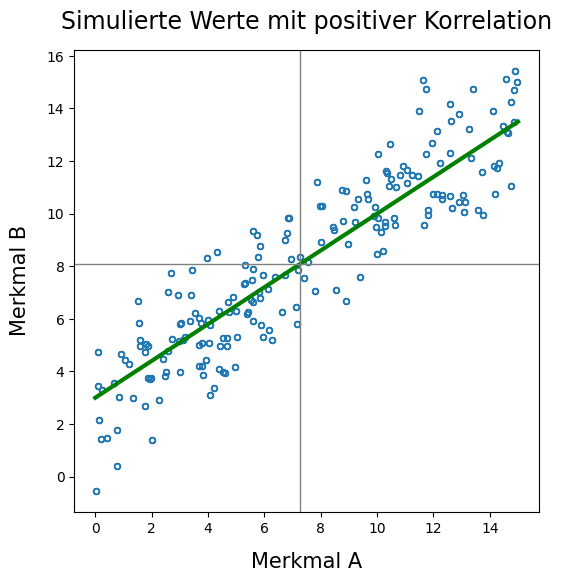

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm

# 200 Werte für A  
A = uniform.rvs(loc=0,scale=15,size=200)

# entsprechendne Werte für B  
B = 0.7*A + 3 + norm.rvs(loc=0,scale=1.5,size=200) 

# speichern die zwei Merkmale in einem DataFrame
df = pd.DataFrame({"A":A,"B":B})

# erstellen ein Figurobjekt
fig = plt.figure(figsize=(6,6))

# zeichnen ein Strudiagramm für A und B
axi = fig.add_subplot(1,1,1)

# exakte Modell einzeichen
x_ = np.linspace(0,15,100)
y_ = [0.7*x+3 for x in x_]
axi.plot(x_,y_, color="green",lw=3)

axi.axhline(B.mean(), color="grey", lw=1)
axi.axvline(A.mean(), color="grey", lw=1)

df.plot.scatter(x = "A", y = "B", ax = axi, marker="$\u25EF$")

axi.set_xlabel("Merkmal A",size=15,labelpad=12)
axi.set_ylabel("Merkmal B",size=15,labelpad=12)
axi.set_title("Simulierte Werte mit positiver Korrelation",size=17,pad=15)

# zeigen Figur
plt.show()

Erwartungsgemäss ist der **Korreklationskoeffizient** für $A$ und $B$ nahe bei 1:

In [2]:
df.corr()

,A,B
A,1.000000,0.909312
B,0.909312,1.000000


### <span style="color:rgb(160,0,86)">Wie finden wir die Parameter des Modells?</span>

Wenn wir nur diese 200 Datenpunkte aus einer Stichprobe haben, kennen wir die **zwei Parameter** $\,\pmb{a=0.7}\,$ und $\,\pmb{b=3}\,$ **des linearen Modells** nicht.

<span style="color:rgb(160,0,86)">***Wir versuchen nun diese zwei Paramter des Modells aus den Daten zu schätzen.***</span>

Für alle 200 Datenpunkte berechnen wir das **Residuum** $$r_i = y_i - \texttt{precidt}(x_i) = y_i - (\pmb{a}\cdot x_i + \pmb{b})$$ und bestimmen die Parameter $\pmb{a}$ und $\pmb{b}$ so, dass die **Summe der Residuenquadrate** $\,\pmb{\mathsf{RSS}}\,$ minimal wird: $$\text{finde }\;\pmb{a}\;\text{ und }\;\pmb{b}\;\text{ so, dass }\; \pmb{\mathsf{RSS}(a,b) = r_1^2+r_2^2+r_3^2+\ldots+r_n^2} \;\text{ minimal }$$  

Im Modul <strong><tt>scipy.optimize</tt></strong> gibt es eine Funktion <strong><tt>minimize()</tt></strong>, mit der wir die beste Lösung für die zwei Parameter $\pmb{a}$ und $\pmb{b}$ finden.

Mit der Funktion <strong><tt>minimize()</tt></strong> aus dem Modul <strong><tt>scipy.optimize</tt></strong> können wir **eine Funktion numerisch minimieren**, also zum Beispiel die Werte $\pmb{a}$ und $\pmb{b}$ so bestimmen, dass die Zielfunktion $\,\pmb{\mathsf{RSS}}\,$ ihren kleinsten Wert annimmt.

Das Verfahren in <strong><tt>minimize()</tt></strong> **ist sehr allgemein**: Man kann damit lineare, nichtlineare, glatte oder auch nicht-glatte Funktionen optimieren.

**Parameter** von <strong><tt>minimize()</tt></strong> sind:

- $\pmb{\texttt{f}}\,$: Die zu minimierende Funktion. <br/> Sie nimmt einen Vektor (oder eine Zahl) als Argument und gibt einen Zahl zurück.
- $\pmb{\texttt{x0}}\,$: Startvektor (oder Startwert) für die Optimierung.
- $\pmb{\texttt{method}}\,$ (optional): Das Optimierungsverfahren <br/> z.B. $\pmb{\texttt{"BFGS"}}$, $\pmb{\texttt{"Nelder-Mead"}}$, $\pmb{\texttt{"Powell"}}$, $\pmb{\texttt{"CG"}}$, $\pmb{\texttt{"L-BFGS-B"}}$ usw.
- Weitere optionale Parameter ...

**Rückgabewert** <strong><tt>result</tt></strong> von <strong><tt>minimize()</tt></strong> enthält:
- $\pmb{\texttt{result.x}}\quad\Longrightarrow\quad$ der Punkt, an dem das Minimum gefunden wurde
- $\pmb{\texttt{result.fun}}\quad\Longrightarrow\quad$ der Funktionswert an diesem Punkt
- $\pmb{\texttt{result.success}}\quad\Longrightarrow\quad$ ob die Optimierung erfolgreich war
- $\pmb{\texttt{result.message}}\quad\Longrightarrow\quad$ Statusmeldung des Algorithmus

In [3]:
from scipy.optimize import minimize

# lineares Modell mit Parameter a und Parameter b
def model(x,a=1,b=0):
    return a*x + b

# die zu minimierende Funktion mit Argumenten a = parameter[0] und 
#                                             b = parameter[1] 
def RSS(parameter):
    residuen = B - model(A,a=parameter[0],b=parameter[1])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.array([0.1,0.1]))
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 408.3392858562396
        x: [ 7.293e-01  2.796e+00]
      nit: 4
      jac: [ 3.815e-06 -3.815e-06]
 hess_inv: [[ 1.364e-04 -9.914e-04]
            [-9.914e-04  9.708e-03]]
     nfev: 18
     njev: 6

Wir können prüfen, ob die **Funktion** $\,\pmb{\mathsf{RRS}}\,$ in der Tat für die **zwei berechneten Parameter** $\,\pmb{\texttt{fit.x[0]}}\,$ und $\,\pmb{\texttt{fit.x[1]}}\,$ minimal ist:

In [4]:
n = 50000
Testwerte_a = uniform.rvs(loc=0,scale=2,size=n)
Testwerte_b = uniform.rvs(loc=0,scale=6,size=n)

Opt_test = True
for i in range(n):
    if RSS((Testwerte_a[i],Testwerte_b[i])) < fit.fun:
        Opt_test = False

print("RSS ist beim Test minimal:",Opt_test)

RSS ist beim Test minimal: True


Mit den **berechneten Schätzungen für die Parameter** $\,\pmb{\hat{a}=\texttt{fit.x[0]}}\,$ und $\,\pmb{\hat{b}=\texttt{fit.x[1]}}\,$ können wir nun die **Prädiktorfunktion** definieren und im Streudiagramm einzeichnen: 

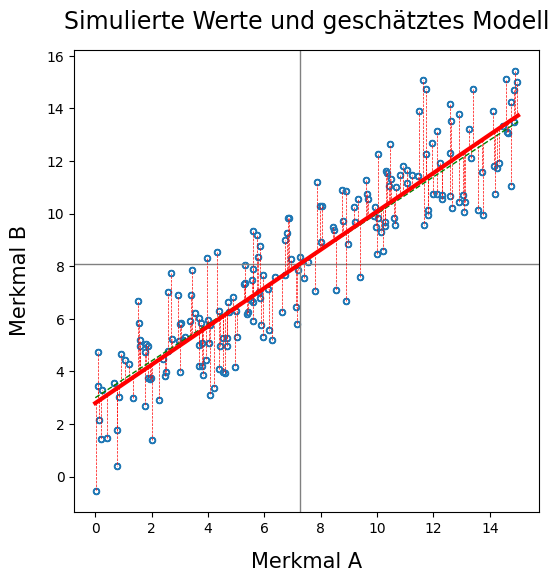

In [5]:
# Prädiktorfunktion definieren
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1])

# Figurobjekt erstellen
fig = plt.figure(figsize=(6,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# horizontale und vertikale Linien durch den Mittelpunkt der Daten
axi.axhline(B.mean(), color="grey", lw=1)
axi.axvline(A.mean(), color="grey", lw=1)

# Residuen einzeichnen (nur zur Demonstration)
axi.vlines(A,predict(A),B,linestyles="dashed",lw=0.5,color="red")

# Streudiagramm zeichen
df.plot.scatter(x = "A", y = "B", ax = axi, marker="$\u25EF$")

# Wahres Modell zeichnen
x_ = np.linspace(0,15,50)
y_ = [0.7*x+3 for x in x_]
axi.plot(x_,y_,color="green",linestyle="dashed",lw=1)

# Prädiktorfunktion zeichnen
y_hat = predict(x_)
axi.plot(x_,y_hat,color="red",lw=3)

# Achsen beschriften
axi.set_xlabel("Merkmal A",size=15,labelpad=12)
axi.set_ylabel("Merkmal B",size=15,labelpad=12)
axi.set_title("Simulierte Werte und geschätztes Modell",size=17,pad=15)

# Figur zeigen
plt.show()

### <span style="color:rgb(160,0,86)">Wie können wir das Modell bewerten?</span>

- Für ein Modell mit einem Prädiktor $\pmb{x}$ können wir den sogenannten **Standardfehler der Residuen** berechen: $$\pmb{\mathsf{RSE} = \sqrt{\frac{\mathsf{RSS}}{n-\textcolor{red}{2}}}=\sqrt{\frac{r_1^2+r_2^2+r_3^2+\ldots+r_n^2}{n-\textcolor{red}{2}}} }$$  
**RSE** (Residual standard Error) ist ein **Gütemass** für ein angepasstes Regressionsmodell. </br> Weil wir **beim Schätzen der Parameter** $\,\pmb{a}\,$ und $\,\pmb{b}\,$ **<span style="color:rgb(256,0,0)">zwei</span> Freiheitsgrade** verlieren (eine Bedingung für die Steigung und eine Bedingung für den Achsenabschnitt), ist die Summe der quadrierten Residuen (RSS) dadurch zu optimistisch. Damit wir die **wahre Standardabweichung der Fehler schätzen**, müssen wir durch $\pmb{n-\textcolor{red}{2}}$ **dividieren**.

- Eine weitere nützliche Metrik für die Anpassung ist das sogenannte **Bestimmtheitsmass**: $$\pmb{R^2=\frac{\mathsf{MQD}\, \{\,\texttt{predict}(x_1),\,\texttt{predict}(x_2),\ldots,\,\texttt{predict}(x_n)\,\}}{\mathsf{MQD}\,\{\,y_1,\,y_2,\ldots,\,y_n\,\}}}$$ Es gilt $\pmb{0\leqslant R^2\leqslant 1}$ und der Wert gibt an, welcher **Bruchteil der mittleren qudratischen Abweichung MQD** das Modell erklären kann. Für ***lineare Modell*** gilt die Beziehung $$\pmb{R^2 = r^2}$$ zwischen dem **Bestimmtheitsmass** $\pmb{R^2}$ und dem   **Korrelationskoeffizient** $\pmb{r}$.   

In [6]:
# Residual standard Error für einen Prädiktor 
RSE = np.sqrt(fit.fun / (df.shape[0] - 2))

print("RSE =",round(RSE,4))
print("Der wahre Standardfehler ist",1.5)

RSE = 1.4361
Der wahre Standardfehler ist 1.5


In [7]:
# Bestimmtheismass R^2
R_squared = predict(A).var() / B.var()

print("R^2 =",round(R_squared,4))
print("r^2 =",round(df.corr().loc["A","B"]**2,4))

R^2 = 0.8268
r^2 = 0.8268


Das Bestimmtheitsmass sagt uns, dass **ungefähr 80% der mittleren quadratsichen Abweichung** durch das Modell erklärt wird. Das können wir auch visualisieren, in dem wir die 
- <span style="color:red;">**mittlere quadratsiche Abweichung im Modell</span>** (links) 
- <span style="color:blue;">**mittlere quadratsiche Abweichung in den Daten**</span> (rechts)

ins Streudiagramm einzeichnen:

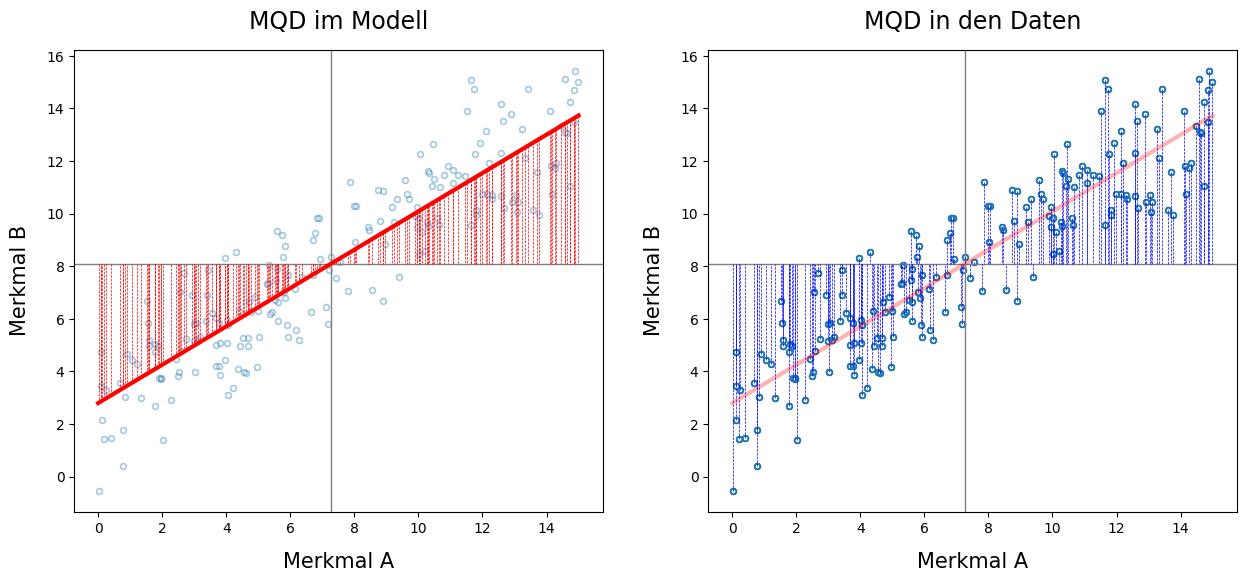

In [8]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,6))

# Koordinatensystem links erstellen
ax1 = fig.add_subplot(1,2,1)

# horizontale und vertikale Linien durch den Mittelpunkt der Daten
ax1.axhline(B.mean(), color="grey", lw=1)
ax1.axvline(A.mean(), color="grey", lw=1)

# mittlere quadratische Abweichung im Modell
ax1.vlines(A,predict(A),predict(A).mean(),
           linestyles="dashed",lw=0.5,color="red")

# Streudiagramm der Daten
df.plot.scatter(x = "A", y = "B", ax = ax1, marker="$\u25EF$",alpha = 0.3)

# geschätztes lineares Modell
x = np.linspace(0,15,50)
ax1.plot(x,predict(x),color="red",lw=3)

# Achsen beschriften
ax1.set_xlabel("Merkmal A",size=15,labelpad=12)
ax1.set_ylabel("Merkmal B",size=15,labelpad=12)
ax1.set_title("MQD im Modell",size=17,pad=15)

# Koordinatensystem rechts erstellen
ax2 = fig.add_subplot(1,2,2)

# horizontale und vertikale Linien durch den Mittelpunkt der Daten
ax2.axhline(B.mean(), color="grey", lw=1)
ax2.axvline(A.mean(), color="grey", lw=1)

# mittlere quadratische Abweichung in den Daten
ax2.vlines(A,B,B.mean(),linestyles="dashed",lw=0.5,color="blue")

# Streudiagramm der Daten
df.plot.scatter(x = "A", y = "B", ax = ax2, marker="$\u25EF$")

# geschätztes lineares Modell
x = np.linspace(0,15,50)
ax2.plot(x,predict(x),color="red",lw=3,alpha=0.3)

# Achsen beschriften
ax2.set_xlabel("Merkmal A",size=15,labelpad=12)
ax2.set_ylabel("Merkmal B",size=15,labelpad=12)
ax2.set_title("MQD in den Daten",size=17,pad=15)

# Figur zeigen 
plt.show()

### <span style="color:rgb(160,0,86)">Wie können wir testen, ob ein Prädiktor einen Einfluss hat?</span>

Der $\pmb{p}$**-Wert** in einer Regressionsanalyse gibt an, ob ein ***beobachteter Regressionsparameter*** rein zufällig entstanden sein könnte. Wir machen also einen Hypothesentest unter der Annahme, dass kein echter ***Zusammenhang zwischen dem Prädiktor und der Zielvariablen*** besteht: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_0:\; a = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a \neq 0}$

Mit einem **Permutationstest** können wir diese Hypothese testen:

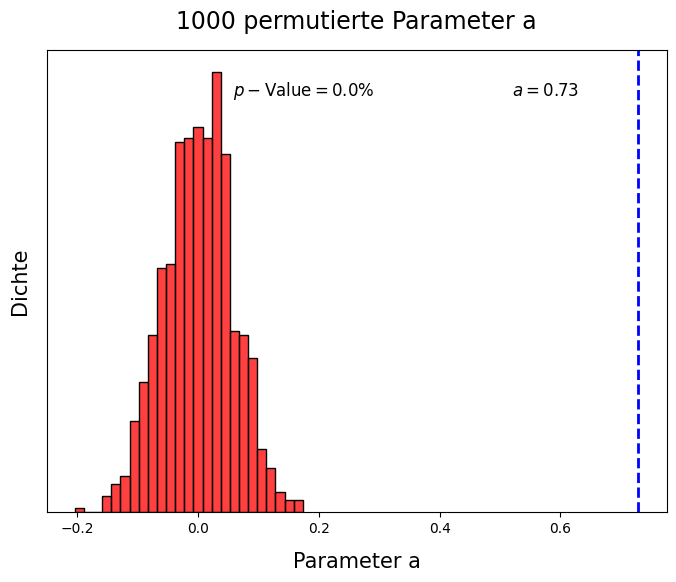

In [9]:
import seaborn as sns
import numpy as np

''' Permutationstest '''
# Anzahl Permutationen
n_permutations = 1000

# Parameter bei den Permutationen
parameter_permuted = []

for _ in range(n_permutations):
    # Werte des Merkmals B zufällig permutieren
    B_permuted = np.random.permutation(B)
    
    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = B_permuted - model(A,a=parameter[0],b=parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(2)+0.1)

    # Geschätzter Parameter a bei den permutierten Daten 
    parameter_permuted.append(fit_permuted.x[0])

# p-Wert berechnen (zweiseitig)
parameter_permuted = np.array(parameter_permuted)
p_value = 100 * np.mean(np.abs(parameter_permuted) >= np.abs(fit.x[0]))


''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die Parameter a aus den Permutationen
sns.histplot(parameter_permuted,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten Parameter a
axi.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
axi.text(0.75,0.9,r"$a=$"+"{m:1.2f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
axi.text(0.3,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
axi.set_title("1000 permutierte Parameter a", fontsize=17,pad=15)
axi.set_xlabel("Parameter a",size=15,labelpad=12)
axi.set_ylabel("Dichte",size=15,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

Wir sehen wie erwartet (so haben wir die Daten $A$ und $B$ erstellt!), dass zwischen den Prädiktoren und der Zielvariable ein Zusammenhang besteht.
- Der beobachtete Parameter $\,\pmb{\hat{a}}\,$ kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%.

Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.

### <span style="color:rgb(160,0,86)">Wie genau ist unsere Schätzung des Parameters?</span>

Mit einem **Konfidenzintervalle** können wir angeben, mit welcher statistischen Sicherheit sich die wahren Regressionsparameter $\pmb{a_i}$ innerhalb eines bestimmten Bereichs befinden. 

Während die geschätzten Parameter $\pmb{\hat{a}_i}$ einer Regression lediglich Punktwerte sind, berücksichtigen Konfidenzintervalle die Unsicherheit, die durch Stichprobenfehler entsteht.

- Ein **95%-Konfidenzintervall** für einen Regressionsparameter bedeutet beispielsweise, dass bei wiederholter Durchführung des Experiments in 95% der Fälle ein Intervall berechnet wird, das den wahren Wert des Parameters enthält. <br/> Liegt das Intervall **vollständig ober- oder unterhalb von null**, deutet das auf einen statistisch signifikanten Einfluss des Prädiktors hin.

- Konfidenzintervalle liefern damit eine **ergänzende Information** zum p-Wert: Während der p-Wert eine Ja/Nein-Aussage über die Signifikanz trifft, zeigen Konfidenzintervalle zusätzlich die **Grössenordnung und Unsicherheit** des geschätzten Effekts.

Das **95%-Konfidenzintervall** finden wir wieder mit dem ***Bootstrap-Verfahren***:

In [10]:
''' Bootstrap Konfidenzintervall für die Parameter a und b'''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte Parameter aus den resamples
parameter_a_samples = []
parameter_b_samples = []

# Grösse der Stichprobe
n = df.shape[0]

# Parameter a und b mit resamples bestimmen
for _ in range(n_bootstrap):
    # Zufälllige resample der Grösse n mit Wiederholungen
    sample = df.sample(n,replace=True)
    A_sample, B_sample = sample["A"], sample["B"] 

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = B_sample - model(A_sample,a=parameter[0],b=parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2))

    # neu geschätzer Parameter speichern 
    parameter_a_samples.append(fit_resample.x[0])
    parameter_b_samples.append(fit_resample.x[1])

# Konfidenzintervalle berechnen (z. B. 95%)
lower_a = np.quantile(parameter_a_samples, 0.025)
upper_a = np.quantile(parameter_a_samples, 0.975)
lower_b = np.quantile(parameter_b_samples, 0.025)
upper_b = np.quantile(parameter_b_samples, 0.975)

print(f"Beobachteter Parameter a          : {fit.x[0]:.4f}")
print(f"95%-Konfidenzintervall (Bootstrap): [{lower_a:.4f}, {upper_a:.4f}]",
      end="\n\n")
print(f"Beobachteter Parameter b          : {fit.x[1]:.4f}")
print(f"95%-Konfidenzintervall (Bootstrap): [{lower_b:.4f}, {upper_b:.4f}]")

Beobachteter Parameter a          : 0.7293
95%-Konfidenzintervall (Bootstrap): [0.6844, 0.7836]

Beobachteter Parameter b          : 2.7958
95%-Konfidenzintervall (Bootstrap): [2.3749, 3.1649]


### <span style="color:rgb(160,0,86)">Wie können wir eine Vorhersage beurteilen?</span>

Bei einem passenden Modell können wir mit der **Prädiktorfunktion** für neue $x$-Werte eine **Prognose** für die $y$-Werte machen:  

In [11]:
# Neuer Wert für x 
a_new = 5.86

# Vorhersage für y  ==>  wahr wäre 0.7*5.86 + 3 = 7.102
b_predict = predict(a_new)

print("Für x =",a_new,"finden wir die Vorhersage y =",b_predict)

Für x = 5.86 finden wir die Vorhersage y = 7.069262184282849


Diese Prognose ist eine **Punktschätzung**!

**Vorhersageintervalle** quantifizieren die ***Unsicherheit bei der Prognose*** einzelner zukünftiger Werte der Zielvariablen auf Basis des Regressionsmodells. 

- Im Gegensatz zum Konfidenzintervall, das den wahren Mittelwert der Zielgrösse für gegebene Prädiktorwerte beschreibt, berücksichtigt das Vorhersageintervall zusätzlich die **zufällige Streuung neuer Beobachtungen** um diesen Mittelwert.

- Ein **95%-Vorhersageintervall** gibt an, dass in 95% der Fälle der tatsächliche Wert der Zielvariable einer neuen Beobachtung innerhalb des angegebenen Intervalls liegen wird – vorausgesetzt, das Modell ist korrekt spezifiziert.

Da das Vorhersageintervall sowohl die **Unsicherheit der Modellschätzung** als auch die **natürliche Streuung neuer Datenpunkte** umfasst, ist es breiter als das Konfidenzintervall. 

- Es ist besonders nützlich, wenn das Ziel nicht die Erklärung, sondern die Prognose zukünftiger Werte ist.

Auch das **95%-Vorhersageintervall** können wir mit dem **Bootstrap-Verfahren** berechnen. 
- Der einzige Unterschied ist, dass wir als **Schätzfehler** einen **zufälligen Wert aus den Residuen** zum Schätzwert addieren.

In [12]:
''' Bootstrap Vorhersageintervall für x = 5.86 '''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte y-Werte (Prognosen)
predictions = []

# Grösse der Stichprobe
n = df.shape[0]

# Mit resamples y bestimmen
for _ in range(n_bootstrap):
    # Zufälllige resample der Grösse n mit Wiederholungen
    sample = df.sample(n,replace=True)
    A_sample, B_sample = sample["A"], sample["B"]

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = B_sample - model(A_sample,a=parameter[0],b=parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2))

    # Vorhersage nach Modell
    def predict(x):
        return model(x,a=fit_resample.x[0],b=fit_resample.x[1])
    b_pred = predict(a_new)
    
    # Vorhersage inkl. zufälligem Fehler (residuenbasiert)
    residuals = B_sample - predict(A_sample)
    error = np.random.choice(residuals)
    b_pred_with_noise = b_pred + error

    predictions.append(b_pred_with_noise)

# 95%-Vorhersageintervall berechnen
lower = np.quantile(predictions, 0.025)
upper = np.quantile(predictions, 0.975)

print(f"Vorhersage mit Modell bei x={a_new}  : {b_predict:.4f}")
print(f"95%-Vorhersageintervall bei x={a_new}: [{lower:.4f}, {upper:.4f}]")

Vorhersage mit Modell bei x=5.86  : 7.0693
95%-Vorhersageintervall bei x=5.86: [4.4297, 9.7053]


***

### <span style="color:rgb(160,0,86)">Beispiele Weinkonsum und Mortalität:</span>

Betrachen wir noch einmal den **Zusammenhang** wischen *Weinkonsum* und *Mortalität*:


In [13]:
wein = pd.read_csv("Daten/Weinkonsum.csv")

wein.corr()

FileNotFoundError: [Errno 2] No such file or directory: 'Daten/Weinkonsum.csv'

In [ ]:
def model(x,a=1,b=0):
    return a*x + b

def RSS(parameter):
    residuen = wein["Mortalität"] - model(wein["Weinkonsum"],
                                          a=parameter[0],
                                          b=parameter[1])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(2))
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 41.93457151499645
        x: [-7.608e-02  7.687e+00]
      nit: 4
      jac: [-9.537e-06 -5.245e-06]
 hess_inv: [[ 5.514e-05 -9.083e-04]
            [-9.083e-04  4.274e-02]]
     nfev: 18
     njev: 6

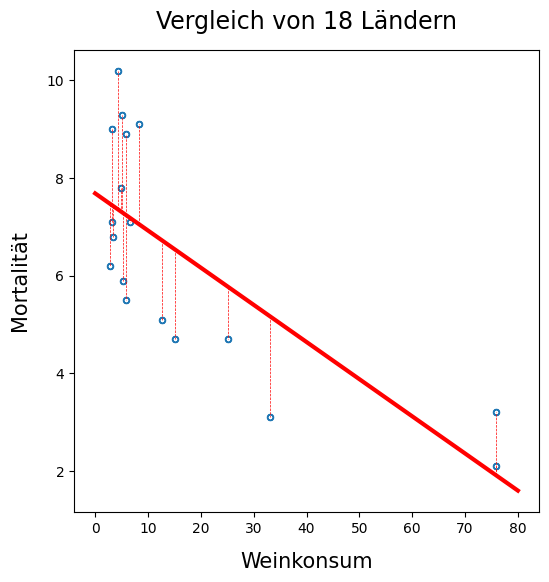

In [ ]:
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1])

x = np.linspace(0,80,50)
y = predict(x)

fig = plt.figure(figsize=(6,6))

axi = fig.add_subplot(1,1,1)
axi.vlines(wein["Weinkonsum"],predict(wein["Weinkonsum"]),wein["Mortalität"],
           linestyles="dashed",lw=0.5,color="red")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität",
                  ax = axi, marker="$\u25EF$")
axi.plot(x,y,color="red",lw=3)

axi.set_title("Vergleich von 18 Ländern", fontsize=17,pad=15)
axi.set_xlabel("Weinkonsum",size=15,labelpad=12)
axi.set_ylabel("Mortalität",size=15,labelpad=12)

plt.show()

In [ ]:
# Residual standard Error für dem Prädiktor 
RSE = np.sqrt(fit.fun / (wein.shape[0] - 2))

print("RSE =",round(RSE,4))

RSE = 1.6189


In [ ]:
# Bestimmtheismass R^2 = R-squared
R_squared = predict(wein["Weinkonsum"]).var() / wein["Mortalität"].var()

print("R^2 =",round(R_squared,4))

R^2 = 0.5559


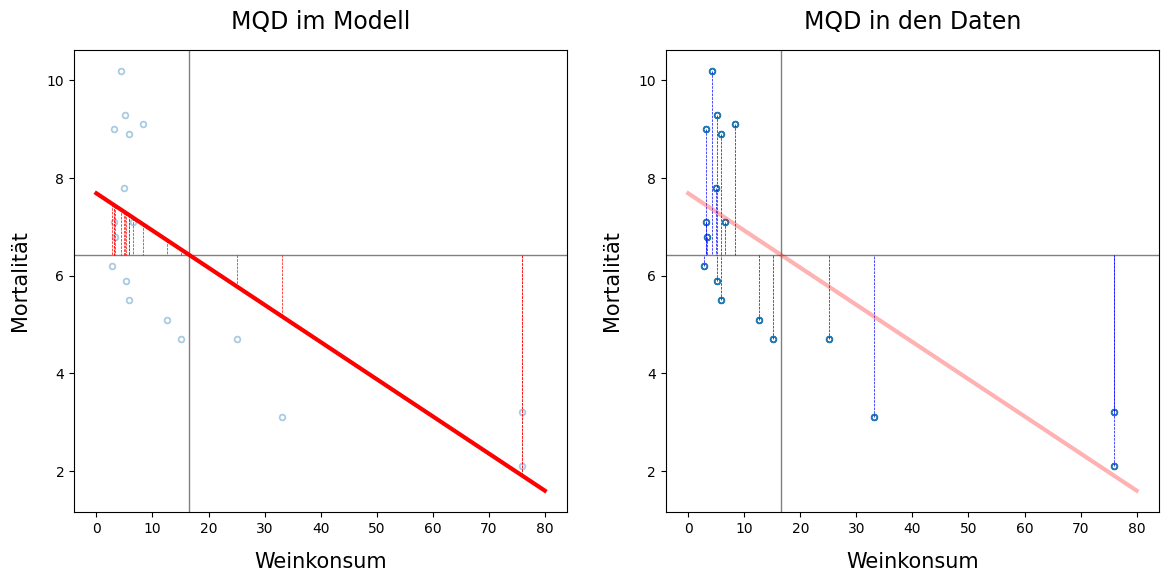

In [ ]:
x = np.linspace(0,80,50)
y = predict(x)

fig = plt.figure(figsize=(14,6))

ax1 = fig.add_subplot(1,2,1)
ax1.axhline(wein["Mortalität"].mean(), color="grey", lw=1)
ax1.axvline(wein["Weinkonsum"].mean(), color="grey", lw=1)
ax1.vlines(wein["Weinkonsum"],predict(wein["Weinkonsum"]),
           predict(wein["Weinkonsum"]).mean(),
           linestyles="dashed",lw=0.5,color="red")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität", 
                  ax = ax1, marker="$\u25EF$",alpha = 0.3)
ax1.plot(x,y,color="red",lw=3)
ax1.set_title("MQD im Modell", fontsize=17,pad=15)
ax1.set_xlabel("Weinkonsum",size=15,labelpad=12)
ax1.set_ylabel("Mortalität",size=15,labelpad=12)

ax2 = fig.add_subplot(1,2,2)
ax2.axhline(wein["Mortalität"].mean(), color="grey", lw=1)
ax2.axvline(wein["Weinkonsum"].mean(), color="grey", lw=1)
ax2.vlines(wein["Weinkonsum"],wein["Mortalität"],wein["Mortalität"].mean(),
           linestyles="dashed",lw=0.5,color="blue")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität", 
                  ax = ax2, marker="$\u25EF$")
ax2.plot(x,y,color="red",lw=3,alpha = 0.3)
ax2.set_title("MQD in den Daten", fontsize=17,pad=15)
ax2.set_xlabel("Weinkonsum",size=15,labelpad=12)
ax2.set_ylabel("Mortalität",size=15,labelpad=12)

plt.show()

- Ein **nicht lineares Modell** könnte besser passen: Zum Beispiel
$$\texttt{predict}(x)=a\cdot e^{b\cdot x}+c \;.$$

In [ ]:
def model(x,a=1,b=1,c=0):
    return a * np.exp(b * x) + c

def RSS(parameter):
    residuen = wein["Mortalität"] - model(wein["Weinkonsum"],
                                          a = parameter[0],
                                          b = parameter[1],
                                          c = parameter[2])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(3))
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 32.519380832945515
        x: [ 6.645e+00 -4.766e-02  2.326e+00]
      nit: 25
      jac: [-4.768e-07 -9.537e-07  0.000e+00]
 hess_inv: [[ 3.678e-01  1.377e-03 -2.668e-01]
            [ 1.377e-03  1.707e-04 -5.789e-03]
            [-2.668e-01 -5.789e-03  3.599e-01]]
     nfev: 120
     njev: 30

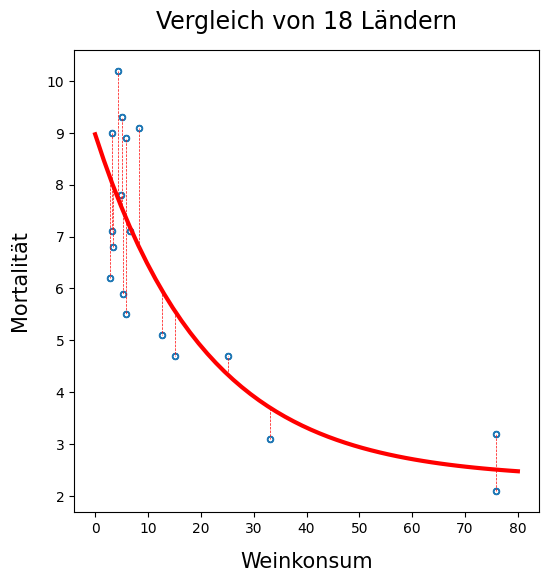

In [ ]:
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1],c=fit.x[2])

fig = plt.figure(figsize=(6,6))

axi = fig.add_subplot(1,1,1)
axi.vlines(wein["Weinkonsum"],predict(wein["Weinkonsum"]),wein["Mortalität"],
           linestyles="dashed",lw=0.5,color="red")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität", 
                  ax = axi, marker="$\u25EF$")
x = np.linspace(0,80,50)
y = predict(x)
axi.plot(x,y,color="red",lw=3)

axi.set_title("Vergleich von 18 Ländern", fontsize=17,pad=15)
axi.set_xlabel("Weinkonsum",size=15,labelpad=12)
axi.set_ylabel("Mortalität",size=15,labelpad=12)

plt.show()

In [ ]:
# Residual standard Error für dem Prädiktor 
RSE = np.sqrt(fit.fun / (wein.shape[0] - 2))

print("RSE =",round(RSE,4))

RSE = 1.4256


In [ ]:
# Bestimmtheismass R^2 = R-squared
R_squared = predict(wein["Weinkonsum"]).var() / wein["Mortalität"].var()

print("R^2 =",round(R_squared,4))

R^2 = 0.6556


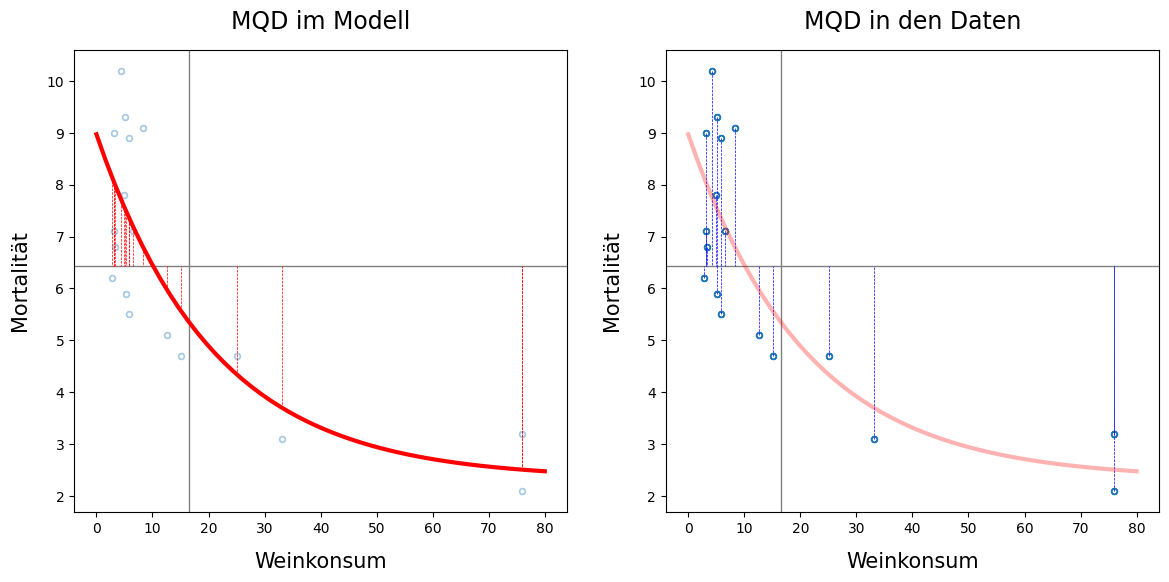

In [ ]:
x = np.linspace(0,80,50)
y = predict(x)

fig = plt.figure(figsize=(14,6))

ax1 = fig.add_subplot(1,2,1)
ax1.axhline(wein["Mortalität"].mean(), color="grey", lw=1)
ax1.axvline(wein["Weinkonsum"].mean(), color="grey", lw=1)
ax1.vlines(wein["Weinkonsum"],predict(wein["Weinkonsum"]),
           predict(wein["Weinkonsum"]).mean(),
           linestyles="dashed",lw=0.5,color="red")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität", 
                  ax = ax1, marker="$\u25EF$",alpha = 0.3)
ax1.plot(x,y,color="red",lw=3)
ax1.set_title("MQD im Modell", fontsize=17,pad=15)
ax1.set_xlabel("Weinkonsum",size=15,labelpad=12)
ax1.set_ylabel("Mortalität",size=15,labelpad=12)


ax2 = fig.add_subplot(1,2,2)
ax2.axhline(wein["Mortalität"].mean(), color="grey", lw=1)
ax2.axvline(wein["Weinkonsum"].mean(), color="grey", lw=1)
ax2.vlines(wein["Weinkonsum"],wein["Mortalität"],wein["Mortalität"].mean(),
           linestyles="dashed",lw=0.5,color="blue")
wein.plot.scatter(x = "Weinkonsum", y = "Mortalität", 
                  ax = ax2, marker="$\u25EF$")
ax2.plot(x,y,color="red",lw=3,alpha = 0.3)
ax2.set_title("MQD in den Daten", fontsize=17,pad=15)
ax2.set_xlabel("Weinkonsum",size=15,labelpad=12)
ax2.set_ylabel("Mortalität",size=15,labelpad=12)

plt.show()

### <span style="color:rgb(160,0,86)">Beispiele Baumwollstaub und Lungenkapazität:</span>

Im folgenden Datensatz wir die **Beziehung** zwischen 

- ***Exposition (Exposure)***: Anzahl Jahre, die ein Arbeiter Baumwollstaub ausgesetzt war

- ***PEFR (Peak Exspiratory Flow Rate)***: Messwert für die Lungenkapazität

In [ ]:
lunge = pd.read_csv("Daten/LungDisease.csv")
print(lunge.shape)
lunge.head()

(122, 2)


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


In [ ]:
lunge.corr().loc["Exposure","PEFR"]

np.float64(-0.27702170106840734)

In [ ]:
def model(x,a=1,b=0):
    return a*x + b

def RSS(parameter):
    residuen = lunge["PEFR"] - model(lunge["Exposure"],
                                     a=parameter[0],
                                     b=parameter[1])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(2))
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1234764.2857143024
        x: [-4.185e+00  4.246e+02]
      nit: 7
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 1.238e-04 -1.874e-03]
            [-1.874e-03  3.277e-02]]
     nfev: 30
     njev: 10

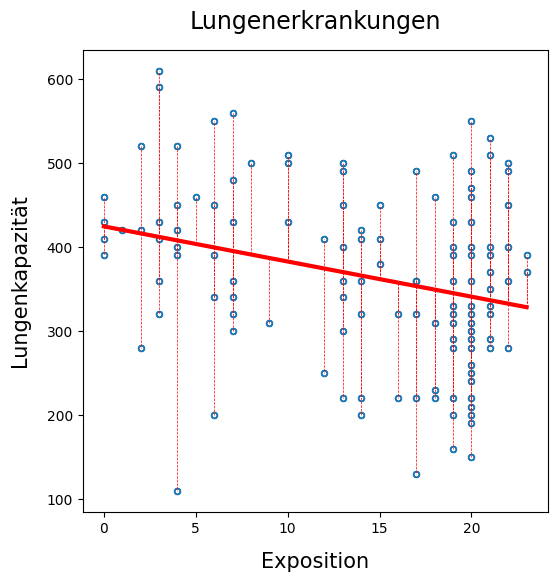

In [ ]:
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1])

fig = plt.figure(figsize=(6,6))

axi = fig.add_subplot(1,1,1)
axi.vlines(lunge["Exposure"],predict(lunge["Exposure"]),lunge["PEFR"],
           linestyles="dashed",lw=0.5,color="red")
lunge.plot.scatter(x = "Exposure", y = "PEFR", ax = axi, marker="$\u25EF$")
x = np.linspace(0,23,50)
y = predict(x)
axi.plot(x,y,color="red",lw=3)

axi.set_title("Lungenerkrankungen", fontsize=17,pad=15)
axi.set_xlabel("Exposition",size=15,labelpad=12)
axi.set_ylabel("Lungenkapazität",size=15,labelpad=12)

plt.show()

In [ ]:
# Residual standard Error für dem Prädiktor 
RSE = np.sqrt(fit.fun / (lunge.shape[0] - 2))

print("RSE =",round(RSE,4))

RSE = 101.4382


In [ ]:
# Bestimmtheismass R^2 = R-squared
R_squared = predict(lunge["Exposure"]).var() / lunge["PEFR"].var()

print("R^2 =",round(R_squared,4))

R^2 = 0.0767


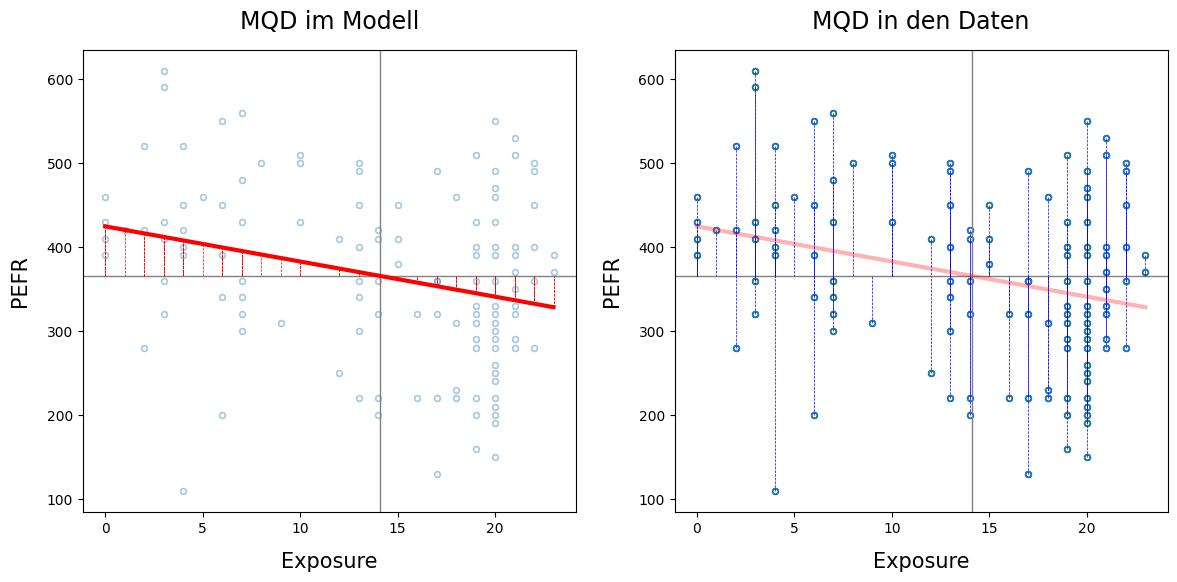

In [ ]:
x = np.linspace(0,23,50)
y = predict(x)

fig = plt.figure(figsize=(14,6))

ax1 = fig.add_subplot(1,2,1)
ax1.axhline(lunge["PEFR"].mean(), color="grey", lw=1)
ax1.axvline(lunge["Exposure"].mean(), color="grey", lw=1)
ax1.vlines(lunge["Exposure"],predict(lunge["Exposure"]),
           predict(lunge["Exposure"]).mean(),
           linestyles="dashed",lw=0.5,color="red")
lunge.plot.scatter(x = "Exposure", y = "PEFR", 
                   ax = ax1, marker="$\u25EF$",alpha = 0.3)
ax1.plot(x,y,color="red",lw=3)
ax1.set_title("MQD im Modell", fontsize=17,pad=15)
ax1.set_xlabel("Exposure",size=15,labelpad=12)
ax1.set_ylabel("PEFR",size=15,labelpad=12)

ax2 = fig.add_subplot(1,2,2)
ax2.axhline(lunge["PEFR"].mean(), color="grey", lw=1)
ax2.axvline(lunge["Exposure"].mean(), color="grey", lw=1)
ax2.vlines(lunge["Exposure"],lunge["PEFR"],lunge["PEFR"].mean(),
           linestyles="dashed",lw=0.5,color="blue")
lunge.plot.scatter(x = "Exposure", y = "PEFR", ax = ax2, marker="$\u25EF$")
ax2.plot(x,y,color="red",lw=3,alpha = 0.3)
ax2.set_title("MQD in den Daten", fontsize=17,pad=15)
ax2.set_xlabel("Exposure",size=15,labelpad=12)
ax2.set_ylabel("PEFR",size=15,labelpad=12)

plt.show()

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>

- Machen Sie einen **Hypothesentest** für den Prädiktor **Exposure**.

- Berechnen Sie ein **Konfidenzintervall** für das Gewicht vom Prädiktor **Exposure**.

- Berechnen Sie ein **Vorhersageintervall** für die Zielgrösse **PEFR** für Arbeiter mit einem Wert ***Exposure***$\pmb{ \;= 10.7}$ **Jahre**. 

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir machen einen Hypothesentest unter der Annahme, dass kein echter Zusammenhang zwischen dem Prädiktor ***Exposure*** und der Zielvariablen ***PEFR*** besteht: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_0:\; a = 0}$.
- Die **Alternativhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_1:\; a \neq 0}$

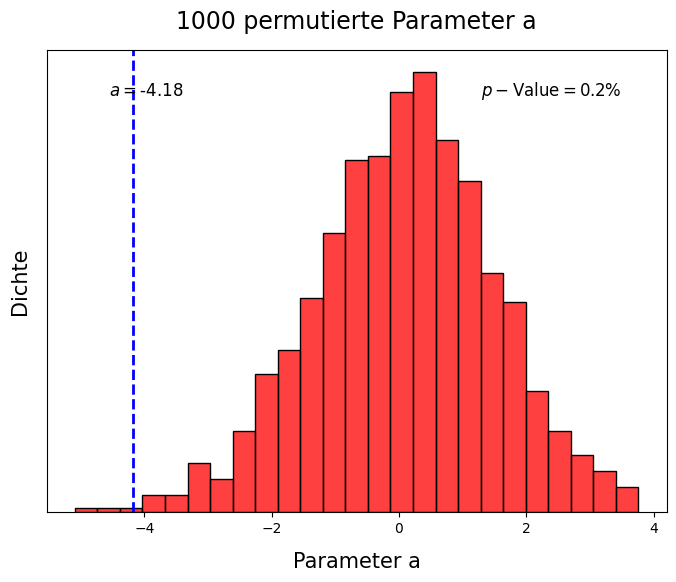

In [ ]:
# Anzahl Resamples
n_permutations = 1000

# Parameter bei den Permutationen
parameter_permuted = []

# Permutationstest
for _ in range(n_permutations):
    # PEFR-Werte zufällig permutieren
    PEFR_permuted = np.random.permutation(lunge["PEFR"])
    
    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = PEFR_permuted - model(lunge["Exposure"],
                                         parameter[0],
                                         parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(2)+0.1)

    # Geschätzter Parameter a der permutierten Daten speichern 
    parameter_permuted.append(fit_permuted.x[0])

# p-Wert berechnen (zweiseitig)
parameter_permuted = np.array(parameter_permuted)
p_value = 100 * np.mean(np.abs(parameter_permuted) >= np.abs(fit.x[0]))

''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die Parameter a aus den Permutationen
sns.histplot(coeffs_permuted,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten Parameter a
axi.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
axi.text(0.1,0.9,r"$a=$"+"{m:1.2f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
axi.text(0.7,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
axi.set_title("1000 permutierte Parameter a", fontsize=17,pad=15)
axi.set_xlabel("Parameter a",size=15,labelpad=12)
axi.set_ylabel("Dichte",size=15,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

---

In nur ca. 0.2% der zufällig permutierten Werte ist ein noch grösseres Gewicht $a$ für den Prädiktor ***Exposure*** entstanden als das beobachtete Gewicht. Das Signifikanzniveau von 5% wird also unterschritten. Daher **lehnen wir die Nullhypothese ab** und gehen davon aus, dass das beobachtete Gewicht des Prädiktors ***Exposure*** nicht mit Zufall erklärbar ist.

Nun berechen wir ein **95%-Konfidenzintervall** für die Parameter $\,\pmb{a}\,$ und $\,\pmb{b}\,$:

In [ ]:
''' Bootstrap Konfidenzintervall für die Parameter a und b'''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte Parameter aus den resamples
parameter_a_samples = []
parameter_b_samples = []

# Grösse der Stichprobe
n = lunge.shape[0]

# Parameter a und b mit resamples bestimmen
for _ in range(n_bootstrap):
    # n = 122 zufällige neue Werte aus lunge 
    sample = lunge.sample(n,replace=True)
    Exposure_sample = np.array(sample["Exposure"])
    PEFR_sample = np.array(sample["PEFR"])

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = PEFR_sample - model(Exposure_sample,
                                       a = parameter[0],
                                       b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2)+0.1)

    # neu geschätzer Parameter speichern 
    parameter_a_samples.append(fit_resample.x[0])
    parameter_b_samples.append(fit_resample.x[1])

# Konfidenzintervall berechnen (95%)
lower_a = np.quantile(parameter_a_samples, 0.025)
upper_a = np.quantile(parameter_a_samples, 0.975)
lower_b = np.quantile(parameter_b_samples, 0.025)
upper_b = np.quantile(parameter_b_samples, 0.975)

print(f"Beobachteter Parameter a          : {fit.x[0]:.4f}")
print(f"95%-Konfidenzintervall (Bootstrap): [{lower_a:.4f}, {upper_a:.4f}]",end="\n\n")
print(f"Beobachteter Parameter b          : {fit.x[1]:.4f}")
print(f"95%-Konfidenzintervall (Bootstrap): [{lower_b:.4f}, {upper_b:.4f}]")

Beobachteter Parameter a          : -4.1846
95%-Konfidenzintervall (Bootstrap): [-6.5141, -1.7321]

Beobachteter Parameter b          : 424.5828
95%-Konfidenzintervall (Bootstrap): [384.4262, 461.4296]


Nun berechnen wir ein **95%-Vorhersageintervall** für die Zielgrösse **PEFR** für Arbeiter mit einem Wert ***Exposure***$\pmb{ \;= 10.7}$ **Jahre**: 

In [ ]:
''' Vorhersage für Arbeiter mit 10.7 Jahren Exposure '''

# neuer Exposure-Wert
Exposure_new = 10.7

# Punktschätzung für den zugehörigen PEFR-Wert
PEFR_predict = predict(Exposure_new)

''' Bootstrap Vorhersageintervall für Arbeiter mit 10.7 Jahren Exposure '''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte y-Werte (Prognosen)
predictions = []

# Grösse der Stichprobe
n = lunge.shape[0]

# Parameter a und b mit resamples bestimmen
for _ in range(n_bootstrap):
    # n = 122 zufällige neue Werte aus lunge 
    sample = lunge.sample(n,replace=True)
    Exposure_sample = np.array(sample["Exposure"])
    PEFR_sample = np.array(sample["PEFR"])

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = PEFR_sample - model(Exposure_sample,
                                       a = parameter[0],
                                       b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2)+0.1)

    # Vorhersage nach Modell
    def predict_resample(x):
        return model(x,a=fit_permuted.x[0],b=fit_permuted.x[1])
    PEFR_pred = predict_resample(Exposure_new)
    
    # Vorhersage inkl. zufälligem Fehler (residuenbasiert)
    residuals = PEFR_sample - predict_resample(Exposure_sample)
    error = np.random.choice(residuals)
    PEFR_pred_with_noise = PEFR_pred + error

    predictions.append(PEFR_pred_with_noise)

# 95%-Vorhersageintervall berechnen
lower = np.quantile(predictions, 0.025)
upper = np.quantile(predictions, 0.975)

print(f"Vorhersage für PEFR mit Modell bei Exposure = {Exposure_new}   : {PEFR_predict:.4f}")
print(f"95%-Vorhersageintervall für PEFR bei Exposure = {Exposure_new} : [{lower:.4f}, {upper:.4f}]")

Vorhersage für PEFR mit Modell bei Exposure = 10.7   : 379.8078
95%-Vorhersageintervall für PEFR bei Exposure = 10.7 : [179.0790, 565.9239]


### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

- Machen Sie eine **lineare Regressionsanalyse** für den Zusammenhang zwischen der ***Zeitspanne*** und der ***Eruptionsdauer*** des **Geysirs Old Faithful** im Yellowstone National Park mit dem Datensatz *geysir.dat*. Aus dem Prädiktor ***Zeitspanne*** soll die  ***Erupionsdauer*** geschätzt werden.

- Berechnen Sie auch ein **Vorhersageintervall** für die ***Eruptionsdauer***, wenn die ***Zeitspanne*** **75 Minuten** beträgt.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir laden die Daten:

In [ ]:
geysir = pd.read_csv("Daten/geysir.dat",delimiter=" ")
geysir.head()

,Tag,Zeitspanne,Eruptionsdauer
1,1,78,4.4
2,1,74,3.9
3,1,68,4.0
4,1,76,4.0
5,1,80,3.5


Zuerst berechnen wir ein **lineares Modell** gemäss $$\;\;\textit{Eruptionsdauer} = \texttt{predict}(\textit{Zeitspanne}) = a\cdot \textit{Zeitspanne} + b$$

In [ ]:
# lineares Modell
def model(x,a=1,b=0):
    return a*x + b

# Summe der quadratischen Residuen
def RSS(parameter):
    residuen = geysir["Eruptionsdauer"] - model(geysir["Zeitspanne"],
                                                a = parameter[0],
                                                b = parameter[1])
    return (residuen**2).sum()

# RSS minimieren liefert Schätzung für die Parameter a und b
fit = minimize(RSS, x0=np.zeros(2)+2)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 29.95031861900299
        x: [ 6.861e-02 -1.410e+00]
      nit: 5
      jac: [-4.768e-07 -9.537e-07]
 hess_inv: [[ 2.806e-05 -1.992e-03]
            [-1.992e-03  1.461e-01]]
     nfev: 21
     njev: 7

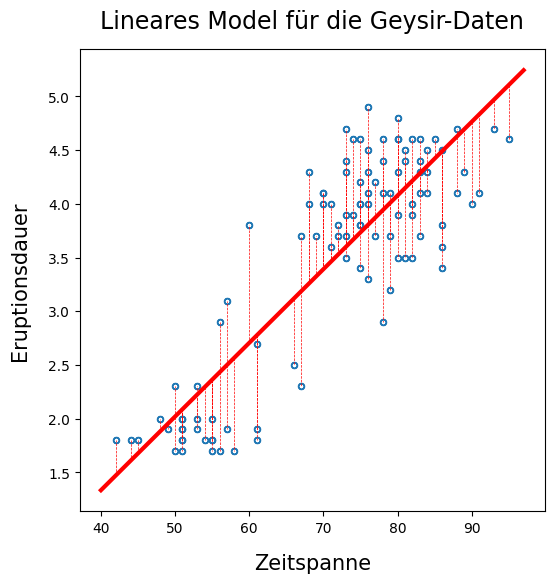

In [ ]:
# Prädiktorfunktion mit den geschätzen Parametern
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1])

# Figurobjekt erstellen
fig = plt.figure(figsize=(6,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Residuen zeichnen
axi.vlines(geysir["Zeitspanne"],predict(geysir["Zeitspanne"]),
           geysir["Eruptionsdauer"],linestyles="dashed",lw=0.5,color="red")

# Streudiagramm für die Geysir-Daten zeichnen
geysir.plot.scatter(x = "Zeitspanne", y = "Eruptionsdauer", ax = axi, marker="$\u25EF$")

# Geschätztes lineares Modell zeichnen
x = np.linspace(geysir["Zeitspanne"].min()-2,geysir["Zeitspanne"].max()+2,50)
y = model(x,fit.x[0],fit.x[1])
axi.plot(x,y,color="red",lw=3)

# Achsen formatieren
axi.set_title("Lineares Model für die Geysir-Daten",size=17,pad=15)
axi.set_xlabel("Zeitspanne",size=15,labelpad=13)
axi.set_ylabel("Eruptionsdauer",size=15,labelpad=13)

# Figur zeigen
plt.show()

Wir beurteilen das Modell mit dem **Bestimmtheitsmass** $R^2$:

In [ ]:
R_squared = predict(geysir["Zeitspanne"]).var() / geysir["Eruptionsdauer"].var()

print(f"Der R-squared Wert ist {R_squared:.4f}")

Der R-squared Wert ist 0.7369


Fast **74% der Variabilität in der Eruptionsdauer** erklären wir mit diesem linearen Modell.

Wir machen einen Hypothesentest unter der Annahme, dass kein echter Zusammenhang zwischen dem Prädiktor ***Zeitspanne*** und der Zielvariablen ***Eruptionsdauer*** besteht: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_0:\; a = 0}$.
- Die **Alternativhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_1:\; a \neq 0}$

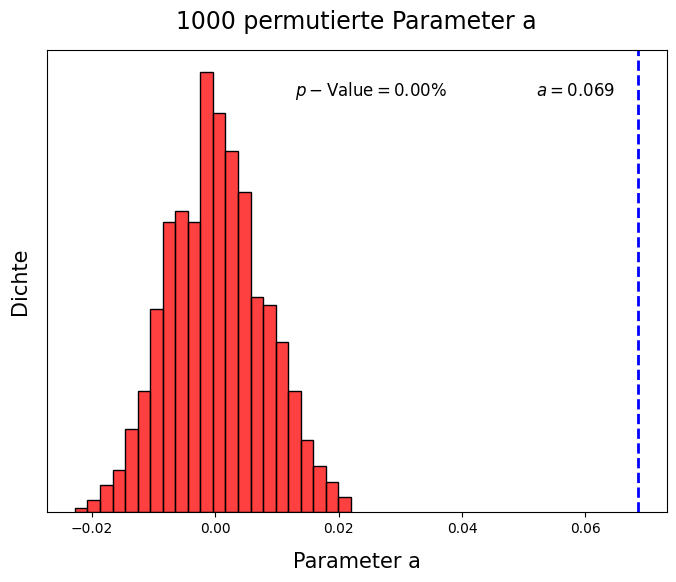

In [ ]:
# Anzahl Resamples
n_permutations = 1000

# Parameter a bei den Permutationen
parameter_permuted = []

# Permutationstest
for _ in range(n_permutations):
    # Werte der Eruptionsdauer zufällig permutieren
    Eruptionsdauer_permuted = np.random.permutation(geysir["Eruptionsdauer"])
    
    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = Eruptionsdauer_permuted - model(geysir["Zeitspanne"],
                                                   a = parameter[0],
                                                   b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(2)+2)

    # Geschätzter Parameter a der permutierten Daten speichern 
    parameter_permuted.append(fit_permuted.x[0])

# p-Wert berechnen (zweiseitig)
parameter_permuted = np.array(parameter_permuted)
p_value = 100 * np.mean(np.abs(parameter_permuted) >= np.abs(fit.x[0]))

''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die Parameter a aus den Permutationen
sns.histplot(parameter_permuted,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten Parameter a
axi.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
axi.text(0.79,0.9,r"$a=$"+"{m:1.3f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
axi.text(0.4,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.2f}%".format(p=p_value),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
axi.set_title("1000 permutierte Parameter a", fontsize=17,pad=15)
axi.set_xlabel("Parameter a",size=15,labelpad=12)
axi.set_ylabel("Dichte",size=15,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

In 0% der zufällig permutierten Werte ist ein noch grösseres Gewicht $a$ für den Prädiktor ***Zeitspanne*** entstanden als das beobachtete Gewicht. Das Signifikanzniveau von 5% wird also klar unterschritten. Daher **lehnen wir die Nullhypothese ab** und gehen davon aus, dass das beobachtete Gewicht des Prädiktors ***Zeitspanne*** nicht mit Zufall erklärbar ist.

Nun berechnen wir ein **95%-Vorhersageintervall** für die Zielgrösse **Eruptionsdauer** nach einer Eruption vor ***Zeitspanne***$\pmb{ \;= 75}$ **Minuten**:

In [ ]:
''' Vorhersage für Eruptionsdauer nach 75 Min. Zeitspanne '''

# neuer Zeitspanne-Wert
Zeitspanne_new = 75

# Punktschätzung für den zugehörigen Eruptionsdauer-Wert
Eruptionsdauer_predict = predict(Zeitspanne_new)

''' Bootstrap Vorhersageintervall für Eruptionsdauer nach 75 Min. '''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte y-Werte (Prognosen)
predictions = []

# Grösse der Stichprobe
n = geysir.shape[0]

# Schätzung für die Eruptionsdauer mit resamples bestimmen
for _ in range(n_bootstrap):
    # n = 107 zufällige neue Werte aus Geysir 
    sample = geysir.sample(n,replace=True)
    Zeitspanne_sample = np.array(sample["Zeitspanne"])
    Eruptionsdauer_sample = np.array(sample["Eruptionsdauer"])

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = Eruptionsdauer_sample - model(Zeitspanne_sample,
                                                 a = parameter[0],
                                                 b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2)+3)

    # Vorhersage nach Modell
    def predict_resample(x):
        return model(x,fit_resample.x[0],fit_resample.x[1])
    Eruptionsdauer_pred = predict_resample(Zeitspanne_new)
    
    # Vorhersage inkl. zufälligem Fehler (residuenbasiert)
    residuals = Eruptionsdauer_sample - predict_resample(Zeitspanne_sample)
    error = np.random.choice(residuals)
    Eruptionsdauer_pred_with_noise = Eruptionsdauer_pred + error

    predictions.append(Eruptionsdauer_pred_with_noise)

# 95%-Vorhersageintervall berechnen
lower = np.quantile(predictions, 0.025)
upper = np.quantile(predictions, 0.975)

print(f"Vorhersage der Eruptionsdauer nach {Zeitspanne_new} Min.                  : {Eruptionsdauer_predict:.4f}")
print(f"95%-Vorhersageintervall für die Eruptionsdauer nach {Zeitspanne_new} Min. : [{lower:.4f}, {upper:.4f}]")

Vorhersage der Eruptionsdauer nach 75 Min.                  : 3.7352
95%-Vorhersageintervall für die Eruptionsdauer nach 75 Min. : [2.8016, 4.8291]


### <span style="color:rgb(160,0,86)">Aufgabe 3</span>

- Machen Sie eine **lineare Regressionsanalyse** für den Zusammenhang zwischen den Tagesrenditen der Indexfonds ***QQQ*** und der ***SPY*** im Datensatz *sp500_data.csv*. Aus dem Prädiktor ***SPY*** soll die Tagesrendite von ***QQQ*** geschätzt werden.

- Berechnen Sie auch ein **Vorhersageintervall** für ***QQQ***, wenn ***SPY*** **bei seinem Median** liegt.

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir laden die Daten:

In [ ]:
import pandas as pd
sp500_px = pd.read_csv("Daten/sp500_data.csv.gz")
fonds = sp500_px[["SPY","QQQ"]] 

fonds.head()

,SPY,QQQ
0,-0.020537,0.0
1,0.185166,0.0
2,0.082281,0.0
3,0.267447,0.0
4,0.020603,0.0


In [ ]:
# Ab wann wurde QQQ erstmals gehandelt?
fonds["QQQ"][fonds["QQQ"]!=0].head()

1542   -0.057200
1543   -0.114399
1544   -0.972394
1545    0.972394
1546    0.200199
Name: QQQ, dtype: float64

In [ ]:
fonds = fonds.iloc[1542:]

fonds.head()

,SPY,QQQ
1542,0.534475,-0.057200
1543,0.697096,-0.114399
1544,-1.208300,-0.972394
1545,0.952664,0.972394
1546,-0.302109,0.200199


Zuerst berechnen wir ein **lineares Modell** gemäss $$\;\;\textit{QQQ} = \texttt{predict}(\textit{SPY}) = a\cdot \textit{SPY} + b$$

In [ ]:
# lineares Modell
def model(x,a=1,b=0):
    return a*x + b

# Summe der quadratischen Residuen
def RSS(parameter):
    residuen = fonds["QQQ"] - model(fonds["SPY"],
                                    a = parameter[0],
                                    b = parameter[1])
    return (residuen**2).sum()

# RSS minimieren liefert Schätzung für die Parameter a und b
fit = minimize(RSS, x0=np.zeros(2)+10)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1573.9958530261727
        x: [ 6.036e-01 -1.477e-02]
      nit: 8
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 1.042e-04 -5.831e-06]
            [-5.831e-06  1.258e-04]]
     nfev: 42
     njev: 14

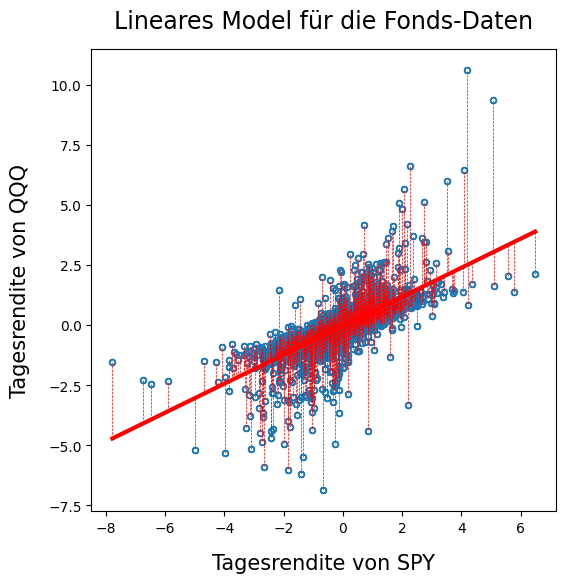

In [ ]:
# Prädiktorfunktion mit den geschätzen Parametern
def predict(x):
    return model(x,a=fit.x[0],b=fit.x[1])

# Figurobjekt erstellen
fig = plt.figure(figsize=(6,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Residuen zeichnen
axi.vlines(fonds["SPY"],predict(fonds["SPY"]),fonds["QQQ"],
           linestyles="dashed",lw=0.5,color="red")

# Streudiagramm für die Fonds-Daten zeichnen
fonds.plot.scatter(x = "SPY", y = "QQQ", ax = axi, marker="$\u25EF$")

# Geschätztes lineares Modell zeichnen
x = np.linspace(fonds["SPY"].min(),fonds["SPY"].max(),50)
y = model(x,fit.x[0],fit.x[1])
axi.plot(x,y,color="red",lw=3)

# Achsen formatieren
axi.set_title("Lineares Model für die Fonds-Daten",size=17,pad=15)
axi.set_xlabel("Tagesrendite von SPY",size=15,labelpad=13)
axi.set_ylabel("Tagesrendite von QQQ",size=15,labelpad=13)

# Figur zeigen
plt.show()

Wir beurteilen das Modell mit dem **Bestimmtheitsmass** $R^2$:

In [ ]:
R_squared = predict(fonds["SPY"]).var() / fonds["QQQ"].var()

print(f"Der R-squared Wert ist {R_squared:.4f}")

Der R-squared Wert ist 0.5095


Rund **51% der Variabilität in der Tagesrendite von QQQ** erklären wir mit diesem linearen Modell.

Wir machen einen Hypothesentest unter der Annahme, dass kein echter Zusammenhang zwischen dem Prädiktor ***SPY*** und der Zielvariablen ***QQQ*** besteht: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_0:\; a = 0}$.
- Die **Alternativhypothese** für das **Gewicht** $\,\pmb{a}$ ist $\quad \pmb{H_1:\; a \neq 0}$

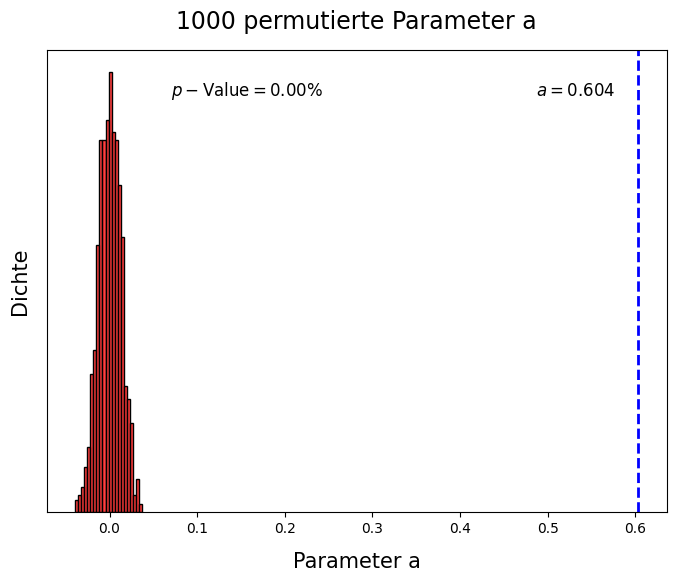

In [ ]:
# Anzahl Resamples
n_permutations = 1000

# Parameter bei den Permutationen
parameter_permuted = []

# Permutationstest
for _ in range(n_permutations):
    # QQQ-Werte zufällig permutieren
    QQQ_permuted = np.random.permutation(fonds["QQQ"])
    
    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = QQQ_permuted - model(fonds["SPY"],
                                        a = parameter[0],
                                        b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(2)+10)

    # Geschätzter Parameter a der permutierten Daten speichern 
    parameter_permuted.append(fit_permuted.x[0])

# p-Wert berechnen (zweiseitig)
parameter_permuted = np.array(parameter_permuted)
p_value = 100 * np.mean(np.abs(parameter_permuted) >= np.abs(fit.x[0]))

''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(8,6))

# Koordinatensystem erstellen
axi = fig.add_subplot(1,1,1)

# Dichtediagramm für die Parameter a aus den Permutationen
sns.histplot(parameter_permuted,stat="density",ax=axi,color="red")

# vertikale Linie beim beobachteten Parameter a
axi.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
axi.text(0.79,0.9,r"$a=$"+"{m:1.3f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
axi.text(0.2,0.9,r"$p-$"+"Value"+r"$ = $"+"{p:1.2f}%".format(p=p_value),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
axi.set_title("1000 permutierte Parameter a", fontsize=17,pad=15)
axi.set_xlabel("Parameter a",size=15,labelpad=12)
axi.set_ylabel("Dichte",size=15,labelpad=12)
axi.set_yticks([])

# Figur zeigen
plt.show()

In 0% der zufällig permutierten Werte ist ein noch grösseres Gewicht $a$ für den Prädiktor ***SPY*** entstanden als das beobachtete Gewicht. Das Signifikanzniveau von 5% wird also klar unterschritten. Daher **lehnen wir die Nullhypothese ab** und gehen davon aus, dass das beobachtete Gewicht des Prädiktors ***SPY*** nicht mit Zufall erklärbar ist.

Nun berechnen wir ein **95%-Vorhersageintervall** für die Zielgrösse **QQQ**, wenn ***SPY*** **bei seinem Median** liegt:

In [ ]:
''' Vorhersage von QQQ für den Median der Tagesrendite von SPY '''

# neuer SPY-Wert
SPY_new = fonds["SPY"].median() 

# Punktschätzung für den zugehörigen QQQ-Wert
QQQ_predict = predict(SPY_new)

''' Bootstrap Vorhersageintervall für QQQ bei median von SPY '''

# Anzahl resamples
n_bootstrap = 1000

# geschätzte y-Werte (Prognosen)
predictions = []

# Grösse der Stichprobe
n = fonds.shape[0]

# Parameter a mit resamples bestimmen
for _ in range(n_bootstrap):
    # n = 4105 neue Werte aus Fonds 
    sample = fonds.sample(n,replace=True)
    SPY_sample = np.array(sample["SPY"])
    QQQ_sample = np.array(sample["QQQ"])

    # neue zu minimierende Funktion
    def RSS(parameter):
        residuen = QQQ_sample - model(SPY_sample,
                                      a = parameter[0],
                                      b = parameter[1])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_resample = minimize(RSS, x0=np.zeros(2)+10)

    # Vorhersage nach Modell
    def predict_resample(x):
        return model(x,fit_resample.x[0],fit_resample.x[1])
    QQQ_pred = predict_resample(SPY_new)
    
    # Vorhersage inkl. zufälligem Fehler (residuenbasiert)
    residuals = QQQ_sample - predict_resample(SPY_sample)
    error = np.random.choice(residuals)
    QQQ_pred_with_noise = QQQ_pred + error

    predictions.append(QQQ_pred_with_noise)

# 95%-Vorhersageintervall berechnen
lower = np.quantile(predictions, 0.025)
upper = np.quantile(predictions, 0.975)

print(f"Vorhersage von QQQ beim Median {SPY_new:.4f} von SPY              : {QQQ_predict:.4f}")
print(f"95%-Vorhersageintervall für QQQ beim Median {SPY_new:.4f} von SPY : [{lower:.4f}, {upper:.4f}]")

Vorhersage von QQQ beim Median 0.0553 von SPY              : 0.0186
95%-Vorhersageintervall für QQQ beim Median 0.0553 von SPY : [-1.3132, 1.0829]


![HSLU](Bilder/LogoHSLU.png)